# **1. ResNet Family 구현**

ResNet-50 뿐만 아니라 ResNet-101, ResNet-152도 구현할 수 있게 코드를 수정해봤습니다.

저번과 마찬가지로, Pytorch에 구현된 것과 동일한 구조, 동일한 파라미터 수를 가지는 ResNet-50, 101, 152을 구현했습니다.

따로 학습 실험을 수행하지는 않았습니다.

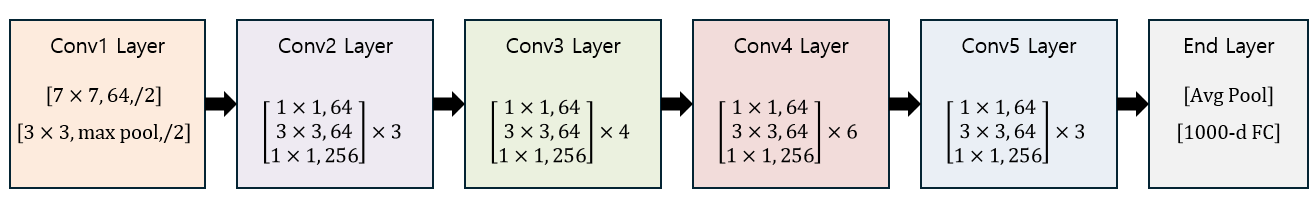

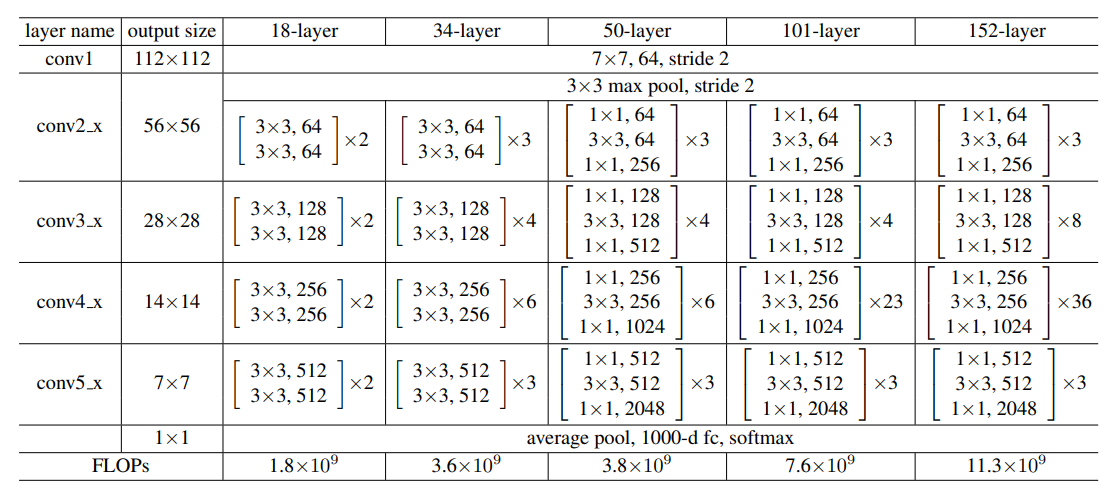

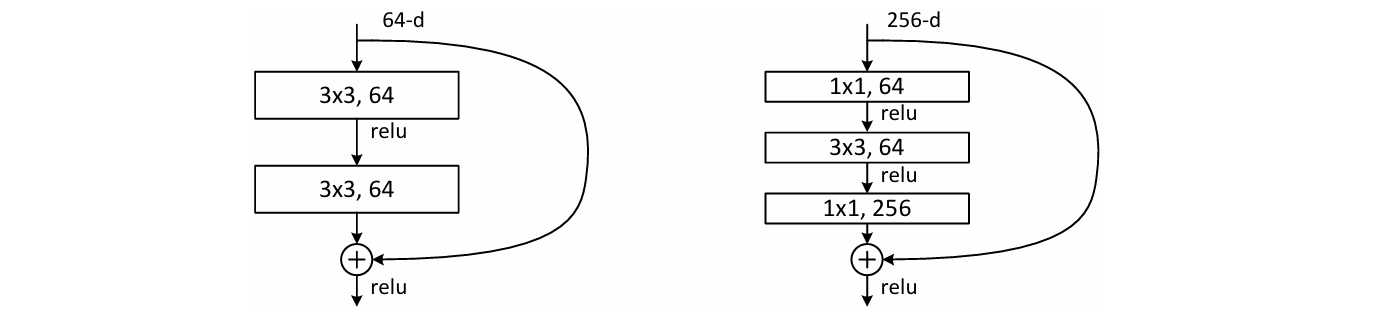

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, norm='bn', relu=True):
        super().__init__()

        layers = []

        layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False))

        if norm == 'bn':
            layers.append(nn.BatchNorm2d(out_channels))
        if relu is True:
            layers.append(nn.ReLU(inplace=True))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        x = self.layers(x)
        return x

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, inter_channels, out_channels, kernel_size=3, stride=1, padding=1, init_block=False):
        # init_block: True로 설정하면 Feature map 축소, False로 설정하면 Feature map 사이즈 유지

        # direct_short_cut: input의 채널 길이가 output의 채널 길이와 같을 땐 곧바로 더하기            (ResNet 논문에 나오는 식 (1) 참고)
        #                   input의 채널 길이가 output의 채널 길이와 다를 땐 1x1 Conv 적용하고 더하기 (ResNet 논문에 나오는 식 (2) 참고)

        super().__init__()
        if init_block:
            init_stride = 2
        else:
            init_stride = 1

        if in_channels == out_channels:
            direct_short_cut = True
        else:
            direct_short_cut = False

        self.conv1 = ConvBlock(in_channels,
                               inter_channels,
                               kernel_size = 1,
                               stride = stride,
                               padding = 0,
                               norm = 'bn',
                               relu = True)

        self.conv2 = ConvBlock(inter_channels,
                          inter_channels,
                          kernel_size = kernel_size,
                          stride = init_stride,
                          padding = 1,
                          norm = 'bn',
                          relu = True)

        self.conv3 = ConvBlock(inter_channels,
                          out_channels,
                          kernel_size = 1,
                          stride = stride,
                          padding = 0,
                          norm = 'bn',
                          relu = False)

        if direct_short_cut and init_stride == 1:
            self.residual = nn.Identity()
        else:
            self.residual = ConvBlock(in_channels,
                                out_channels,
                                kernel_size = 1,
                                stride = init_stride,
                                padding = 0,
                                norm = 'bn',
                                relu = False)

        self.relu = nn.ReLU(inplace=True)

        for layer in self.conv3.layers:
            if isinstance(layer, nn.BatchNorm2d):
                nn.init.constant_(layer.weight, 0.0)

    def forward(self, x):
        y = self.conv1(x)
        y = self.conv2(y)
        y = self.conv3(y)
        y = y + self.residual(x)
        y = self.relu(y)
        return y

In [ ]:
class ResNet(nn.Module):
    def __init__(self, in_channels, out_channels, nker = 64, blk_num = [3,4,6,3]):
        super().__init__()

        self.enc = ConvBlock(in_channels, nker, kernel_size = 7, stride = 2, padding = 3, norm = 'bn', relu = True) # 이 레이어를 통과하면 feature_map = (112x112)
        self.max_pool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding=1)                                        # 이 레이어를 통과하면 feature_map = (56x56)

        layers = []

        input_width = nker
        for i, num in enumerate(blk_num):
            for k in range(num):
                if i != 0 and k == 0:
                    layers.append(ResBlock(input_width, nker, 4*nker, init_block=True))
                else:
                    layers.append(ResBlock(input_width, nker, 4*nker, init_block=False))
                input_width = 4*nker
            nker *= 2

        self.conv = nn.Sequential(*layers)

        self.end_net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(2*nker, out_channels),
        )

    def forward(self, x):
        x = self.enc(x)
        x = self.max_pool(x)
        x = self.conv(x)
        x = self.end_net(x)
        return x

In [ ]:
# 모델 출력 확인
model = ResNet(3, 1000, blk_num = [3,4,6,3]) # ResNet-50
model = ResNet(3, 1000, blk_num = [3,4,23,3]) # ResNet-101
model = ResNet(3, 1000, blk_num = [3,8,36,3]) # ResNet-152

input = torch.randn((2,3,224,224))
output = model(input)
print(f"output: {output.shape}")

total_param = 0
for param in model.parameters():
    total_param += param.numel()
print(f"num of param: {total_param}")

output: torch.Size([2, 1000])
num of param: 60192808
